In [1]:
from google.colab import drive
drive.mount('/gdrive')


Mounted at /gdrive


In [17]:
import time
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
import matplotlib.pyplot as plt
from sklearn import linear_model
from sklearn.metrics import mean_squared_error
from itertools import combinations

data = pd.read_csv("/gdrive/My Drive/ML/data/Credit.csv")
data

,Unnamed: 0,Income,Limit,Rating,Cards,Age,Education,Gender,Student,Married,Ethnicity,Balance
0,1,14.891,3606,283,2,34,11,Male,No,Yes,Caucasian,333
1,2,106.025,6645,483,3,82,15,Female,Yes,Yes,Asian,903
2,3,104.593,7075,514,4,71,11,Male,No,No,Asian,580
3,4,148.924,9504,681,3,36,11,Female,No,No,Asian,964
4,5,55.882,4897,357,2,68,16,Male,No,Yes,Caucasian,331
...,...,...,...,...,...,...,...,...,...,...,...,...
395,396,12.096,4100,307,3,32,13,Male,No,Yes,Caucasian,560
396,397,13.364,3838,296,5,65,17,Male,No,No,African American,480
397,398,57.872,4171,321,5,67,12,Female,No,Yes,Caucasian,138
398,399,37.728,2525,192,1,44,13,Male,No,Yes,Caucasian,0


In [18]:
credit = data.drop(columns=["Unnamed: 0"])
credit.head()

credit = pd.get_dummies(credit, columns = ['Gender', 'Student','Married','Ethnicity'],drop_first = True)
credit.head(3)

def fit_linear_reg(X,Y):
    #Fit linear regression model and return RSS and R squared values
    model_k = linear_model.LinearRegression(fit_intercept = True)
    model_k.fit(X,Y)
    RSS = mean_squared_error(Y,model_k.predict(X)) * len(Y)
    R_squared = model_k.score(X,Y)
    return RSS, R_squared

from tqdm import tnrange, tqdm_notebook
from ipywidgets import IntProgress

#Initialization variables
Y = credit.Balance
X = credit.drop(columns = 'Balance', axis = 1)
k = 11
RSS_list, R_squared_list, feature_list = [],[], []
numb_features = []


In [19]:
k = 2
list(combinations(X.columns,k))

[('Income', 'Limit'),
 ('Income', 'Rating'),
 ('Income', 'Cards'),
 ('Income', 'Age'),
 ('Income', 'Education'),
 ('Income', 'Gender_Female'),
 ('Income', 'Student_Yes'),
 ('Income', 'Married_Yes'),
 ('Income', 'Ethnicity_Asian'),
 ('Income', 'Ethnicity_Caucasian'),
 ('Limit', 'Rating'),
 ('Limit', 'Cards'),
 ('Limit', 'Age'),
 ('Limit', 'Education'),
 ('Limit', 'Gender_Female'),
 ('Limit', 'Student_Yes'),
 ('Limit', 'Married_Yes'),
 ('Limit', 'Ethnicity_Asian'),
 ('Limit', 'Ethnicity_Caucasian'),
 ('Rating', 'Cards'),
 ('Rating', 'Age'),
 ('Rating', 'Education'),
 ('Rating', 'Gender_Female'),
 ('Rating', 'Student_Yes'),
 ('Rating', 'Married_Yes'),
 ('Rating', 'Ethnicity_Asian'),
 ('Rating', 'Ethnicity_Caucasian'),
 ('Cards', 'Age'),
 ('Cards', 'Education'),
 ('Cards', 'Gender_Female'),
 ('Cards', 'Student_Yes'),
 ('Cards', 'Married_Yes'),
 ('Cards', 'Ethnicity_Asian'),
 ('Cards', 'Ethnicity_Caucasian'),
 ('Age', 'Education'),
 ('Age', 'Gender_Female'),
 ('Age', 'Student_Yes'),
 ('Age'

In [20]:
#Looping over k = 1 to k = 11 features in X
stime = time.time()
for k in range(1,len(X.columns) + 1):

    #Looping over all possible combinations: from 11 choose k
    for combo in combinations(X.columns,k):
        tmp_result = fit_linear_reg(X[list(combo)],Y)   #Store temp result
        RSS_list.append(tmp_result[0])                  #Append lists
        R_squared_list.append(tmp_result[1])
        feature_list.append(combo)
        numb_features.append(len(combo))

print(time.time() - stime)

#Store in DataFrame
df = pd.DataFrame({'numb_features': numb_features,'RSS': RSS_list, 'R_squared':R_squared_list,'features':feature_list})
df

13.640051364898682


,numb_features,RSS,R_squared,features
0,1,6.620874e+07,0.214977,"(Income,)"
1,1,2.171566e+07,0.742522,"(Limit,)"
2,1,2.143512e+07,0.745848,"(Rating,)"
3,1,8.370950e+07,0.007475,"(Cards,)"
4,1,8.433963e+07,0.000003,"(Age,)"
...,...,...,...,...
2042,10,3.949432e+06,0.953172,"(Income, Limit, Rating, Age, Education, Gender..."
2043,10,3.839044e+06,0.954481,"(Income, Limit, Cards, Age, Education, Gender_..."
2044,10,4.117780e+06,0.951176,"(Income, Rating, Cards, Age, Education, Gender..."
2045,10,1.461789e+07,0.826679,"(Limit, Rating, Cards, Age, Education, Gender_..."


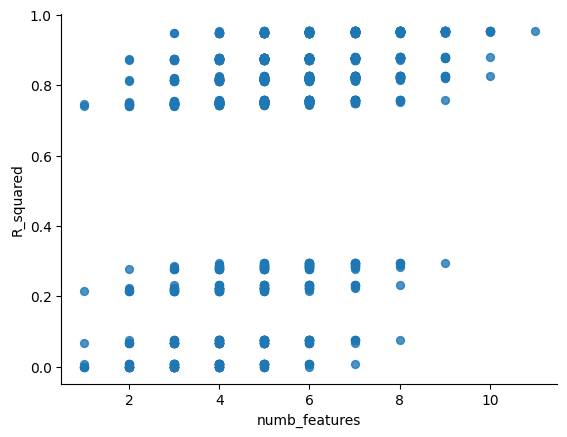

In [12]:
# @title numb_features vs R_square

from matplotlib import pyplot as plt
df.plot(kind='scatter', x='numb_features', y='R_squared', s=32, alpha=.8)
plt.gca().spines[['top', 'right',]].set_visible(False)

In [13]:
df.sort_values(by=['RSS'], inplace=True)
df

,numb_features,RSS,R_squared,features
2046,11,3.786730e+06,0.955102,"(Income, Limit, Rating, Cards, Age, Education,..."
2040,10,3.791345e+06,0.955047,"(Income, Limit, Rating, Cards, Age, Gender_Fem..."
2037,10,3.793349e+06,0.955023,"(Income, Limit, Rating, Cards, Age, Education,..."
2035,10,3.793418e+06,0.955022,"(Income, Limit, Rating, Cards, Age, Education,..."
2039,10,3.798000e+06,0.954968,"(Income, Limit, Rating, Cards, Age, Education,..."
...,...,...,...,...
48,2,8.433703e+07,0.000034,"(Age, Married_Yes)"
8,1,8.433720e+07,0.000032,"(Married_Yes,)"
50,2,8.433872e+07,0.000014,"(Age, Ethnicity_Caucasian)"
10,1,8.433900e+07,0.000011,"(Ethnicity_Caucasian,)"


In [9]:
X.shape, Y.shape

((400, 11), (400,))

In [14]:
from sklearn.feature_selection import SequentialFeatureSelector as SFS
lin_model= linear_model.LinearRegression()

sfs1 = SFS(lin_model, n_features_to_select=5)

sfs1 = sfs1.fit(X, Y)

In [15]:
X.columns

Index(['Income', 'Limit', 'Rating', 'Cards', 'Age', 'Education',
       'Gender_Female', 'Student_Yes', 'Married_Yes', 'Ethnicity_Asian',
       'Ethnicity_Caucasian'],
      dtype='object')

In [16]:
sfs1.get_feature_names_out()

array(['Income', 'Limit', 'Rating', 'Cards', 'Student_Yes'], dtype=object)